In [1]:
import ToyMaker as tmkr
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
%%time
def k_r():
    return 2

def gamma_r(Xr):
    return (1/5) * Xr

species = {
            't':    0., 
            'cell': 0,
            'size': tmkr.birth_size(),
            'Xr': 0.,
}
reactions = {

    k_r: {'create': ['Xr']},
    gamma_r:{'destroy': ['Xr']},
    'division': {'dilute': ['Xr']}

}

tmax = 720
sampling_time = 1
cell = 1
cells = 5000

sim = tmkr.Simulate_Division(species, reactions, tmax, sampling_time, cell, doubling_time=18.)
# [print(sim[i]) for i in range(len(sim))];

CPU times: user 58.5 ms, sys: 29.3 ms, total: 87.8 ms
Wall time: 77.8 ms


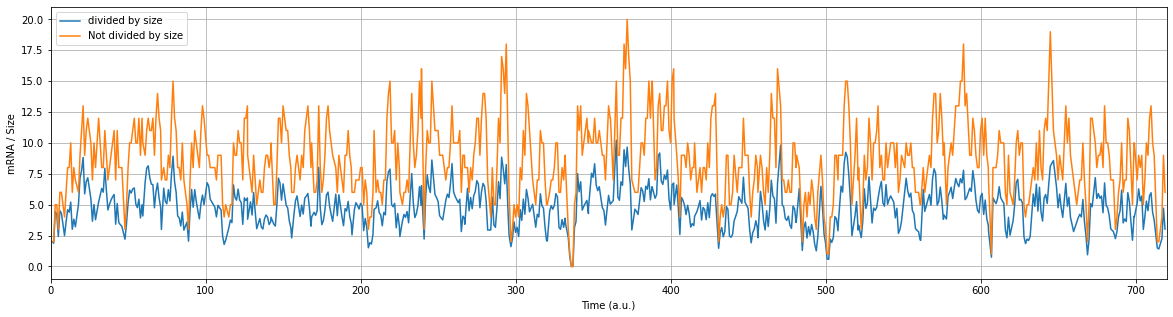

In [3]:
fig, ax = plt.subplots(figsize=(20,5))
plt.plot(sim[:,0],sim[:,3]/sim[:,2], label='divided by size')
plt.plot(sim[:,0],sim[:,3], label='Not divided by size')
plt.xlim(0, tmax)
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA / Size')
plt.grid(True)
plt.legend(loc='best')

Text(0, 0.5, 'Size')

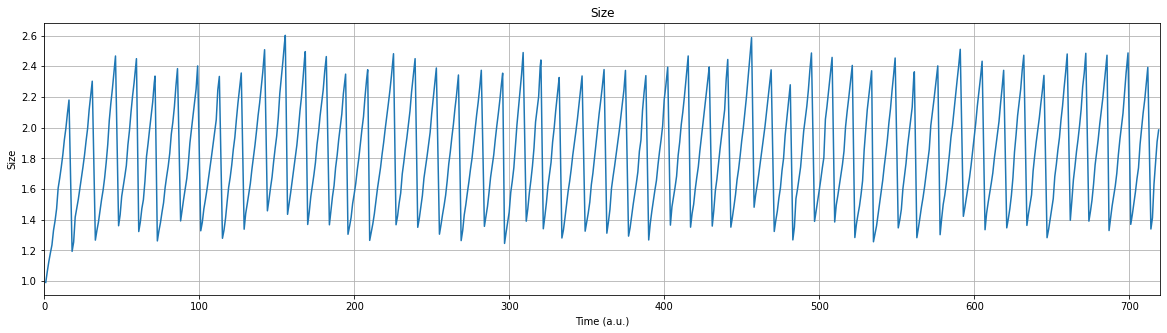

In [4]:
size = [sim[i][2] for i in range(len(sim))]
fig, ax = plt.subplots(figsize=(20,5))
plt.plot(sim[:,0],size)
plt.title('Size')
plt.grid(True)
plt.xlim(0, tmax)
plt.xlabel('Time (a.u.)')
plt.ylabel('Size')

In [5]:
%%time
sims = [tmkr.Simulate_Division(species, reactions, tmax, sampling_time, c) for c in tqdm(range(cells))]

100%|██████████| 5000/5000 [05:57<00:00, 13.97it/s]

CPU times: user 6min 1s, sys: 18.4 s, total: 6min 20s
Wall time: 5min 57s


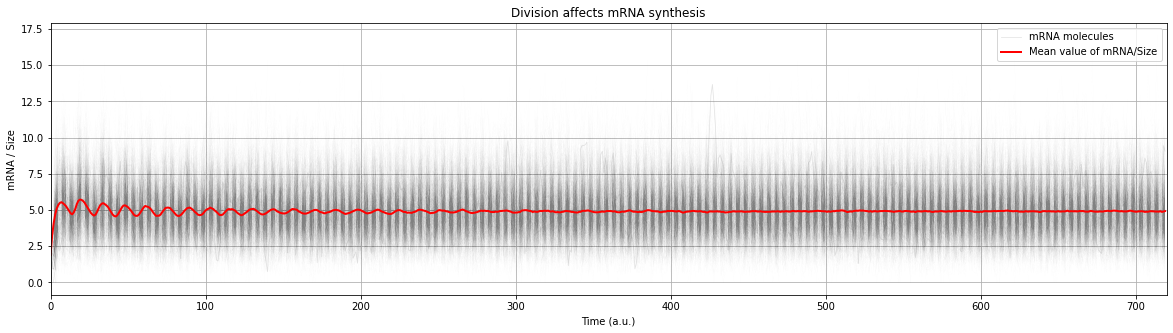

In [6]:
fig, ax = plt.subplots(figsize=(20,5))

time_arr = [sims[c][:,0] for c in range(cells)]
size_arr = [sims[c][:,2] for c in range(cells)]
rna_arr = [sims[c][:,3] for c in range(cells)]

mean_mrna = tmkr.get_mean_per_cell_division(cells=sims, samples=cells, tmax=tmax, species_idx=3, size_idx=2)

[plt.plot(time_arr[c], rna_arr[c]/size_arr[c], lw=0.01, color='grey', alpha=0.2) for c in range(cells if cells <= 1000 else 1000)];
plt.plot(time_arr[0], rna_arr[0]/size_arr[0], lw=0.8, color='grey', label='mRNA molecules', alpha=0.2)
plt.plot(mean_mrna, color='red', lw=2,label='Mean value of mRNA/Size')
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA / Size')
plt.xlim(0, tmax)
# plt.ylim(0, 30)
# plt.hlines((k_r()/gamma_r()), 0, tmax, color='red', label='Theoretical mRNA levels at steady state')
plt.title('Division affects mRNA synthesis')
plt.legend(loc='upper right')
plt.grid(True)

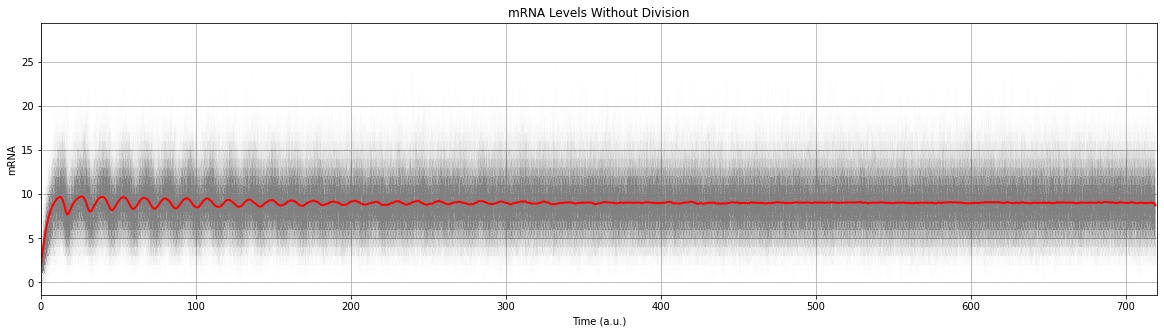

In [8]:
fig, ax = plt.subplots(figsize=(20,5))

time_arr = [sims[c][:,0] for c in range(cells)]
size_arr = [sims[c][:,2] for c in range(cells)]
rna_arr = [sims[c][:,3] for c in range(cells)]

mean_mrna = tmkr.get_mean_per_cell(cells=sims, samples=cells, tmax=tmax, species_idx=3)
[plt.plot(time_arr[c], rna_arr[c], lw=0.05, color='grey', alpha=0.05) for c in range(cells if cells <= 1000 else 1000)];
plt.plot(mean_mrna, color='red', lw=2,label='Mean value of mRNA/Size')
plt.title('mRNA Levels Without Division')
plt.xlabel('Time (a.u.)')
plt.ylabel('mRNA')
plt.xlim(0, tmax)
plt.grid(True)
# plt.hlines((k_r()/gamma_r()), 0, tmax, color='red')

### Steady State

#### Simulation: 

In [7]:
# mean_mrna = tmkr.get_mean_per_cell_division(cells=sims, samples=cells, tmax=tmax, species_idx=3, size_idx=2, single_value=True)
mean_mrna = tmkr.get_mean_per_cell(cells=sims, samples=cells, tmax=tmax, species_idx=3, single_value=True)
mean_mrna

9.030174000000002

#### Theoretical

In [9]:
mu = np.log(2)/18.
ss_d = (k_r() - mu)/gamma_r(Xr=1)
ss_d

9.807459116511126

In [10]:
ss = k_r() / (mu)
ss

51.937021472002684

In [11]:
ss = k_r()/gamma_r(Xr=1)
ss

10.0